<p class="h1">ECE 447 - Notebook 12</p>
<p class="h2">Clustering</p>

The fundamental difference between supervised and unsupervised learning is that in supervised learning, the data is labeled. In unsupervised learning, data is not labeled. The goal for unsupervised learning is to find some structure in the unlabed dataset, such as clustering them into different sections. 

Unsupervised learning algorithms can be "clustered" into different categories, like the following.
* Clustering algorithms
* Data compression, such as Principal Component Analysis (PCA)
* Unsupervised anamoly detection
* Some neural networks, such as Autoencoders

In this part of the course, we are going to talk about the following topics.
* Different types of unsupervised algorithms
* Details of clustering as an important unsupervised task
* Implementing and visualizing the K-means algorithm from scratch
* The elbow method to find the best number of clusters for the K-means algorithm
* Short descriptions of other famous clustering algorithms as well as their pros and cons
* An introduction to the *scikit-learn* machine learning package and implementing K-means using that as a tutorial
* Implementing these clustering algorithms using *scikit-learn* and testing them on different datasets for comparison

<p class="h2">Clustering</p>

Clustering can have different applications, such as:
* Clustering news articles into various news topics
* Segmentation of market
* Clustering a social network based on political views
* Finding different categories of users and based on this develop relevant marketing campaigns for each group to improve retention of a service

There are different learning algorithms that can do clustering, such as K-means and mean-shift.


## K-Means Implementation

In this section, we are going to implement the K-means algorithm and apply it to some randomly generated data.

We first generate some random data (three clusters):


In [1]:
import numpy as np # Matrix processing
from matplotlib import pyplot as plt # Plotting

*** data matrix shape:  (600, 2)


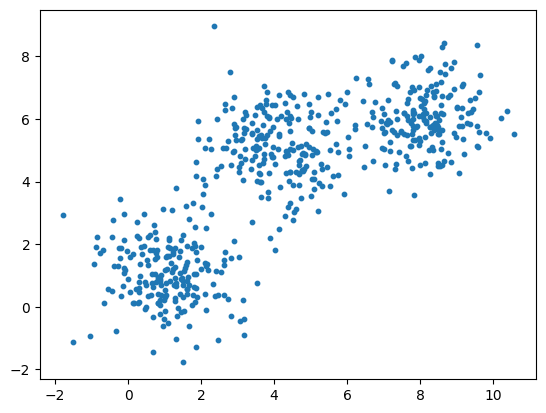

In [2]:
def create_random_data():
  np.random.seed(1)
  # Three centroids are set
  centroid_1 = np.array([1,1])
  centroid_2 = np.array([4,5])
  centroid_3 = np.array([8,6])

  # Generating random data and placing them around three centroids
  data_1 = np.random.randn(200,2) + centroid_1
  data_2 = np.random.randn(200,2) + centroid_2
  data_3 = np.random.randn(200,2) + centroid_3

  data = np.concatenate((data_1, data_2, data_3), axis = 0)
  return data


data = create_random_data()
plt.scatter(data[:,0], data[:,1], s=10) # s is the marker size

print('*** data matrix shape: ', data.shape)

We can see that three distinct clusters are available for our testing. Now let's start coding the main algorithm.

We have one hyperparameter, which is the number of clusters. Let's assume we know the data structure and with an educated guess, the number of clusters is set to 3.

In [12]:
# Number of clusters
k = 3
# Number of training data (in this case - 600)
n = data.shape[0]
# Number of features in data (in this case - 2)
c = data.shape[1]

As mentioned earlier, the first step is to randomly initialize the k (in this case 3) centroids. Calculating random initialization that takes into account the mean and standard deviation of the dataset. We assume the data has normal distribution. It is fine that the assumption is not accurate as the next steps of the algorithm are going to improve our results.

In [13]:
mean = np.mean(data, axis = 0)
std = np.std(data, axis = 0)
centroids = np.random.randn(k,c)*std + mean

print('Shape of centroids matrix: {0}'.format(centroids.shape))

Shape of centroids matrix: (3, 2)


We are now going to plot the randomly intiated centroids to see how well they are. 

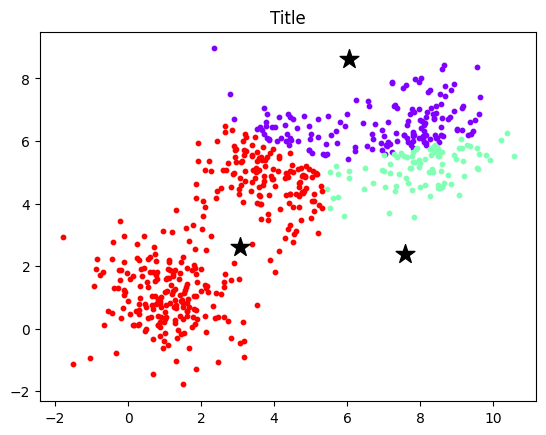

In [14]:
import time
import pylab as pl
from IPython import display
import matplotlib.cm as cm

def plot_clusters(data, clusters, centroids, title):
    pl.gcf().clear()
    
    k = len(centroids)
    
    # Plotting Data Points
    if clusters is None:
        pl.scatter(data[:,0], data[:,1], s=10, c='steelblue')
        pl.scatter(centroids[:,0], centroids[:,1], marker='*', c='r', s=150)
    else:
        # Different color clusters
        colors = cm.rainbow(np.linspace(0, 1, k))
        for i in range(k):
            cluster_data = data[clusters == i, :]
            pl.scatter(cluster_data[:,0], cluster_data[:,1], s=10, color=colors[i])
            pl.scatter(centroids[i,0], centroids[i,1], marker='*', color='k', s=200)
            
    pl.title(title)
    display.display(pl.gcf())
    display.clear_output(wait=True)
    
# Testing Plot
k = 3
distances = np.zeros((n, k))  
for i in range(k):
    distances[:, i] = np.linalg.norm(data - centroids[i, :], axis=1)
clusters = np.argmin(distances, axis=1)
plot_clusters(data, clusters, centroids, 'Title')

Now that we have the centroids initialized, it's time to do the updates in multiple iterations as follows:


1.   Categorizing each data point under a centroid's cluster, based on their closeness to the centroid
2.   Updating centroid locations based on the average location of their cluster members 

Remembering parameter names:
* k: number of clusters (3 in this case)
* n: number of data points (600 in this case)
* c: number of features (2 in this case)

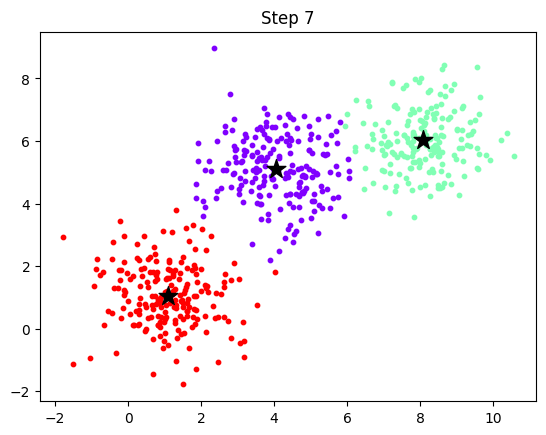

In [15]:

# Centroids matrix shape: (k, c)
old_centroids = np.zeros(centroids.shape)
# n: number of training data; k: number of clusters
# Each row contains distance of a data point to a cluster's centroid
distances = np.zeros((n, k))  

# L2-norm for error calculation: 
# https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.linalg.norm.html 
error = np.linalg.norm(centroids - old_centroids)

# While error is not zero, continue iteration to update clusters
step = 1
while error > 1e-9:
  # Step 1: Marking each data point under each cluster
  
  # Measuring the distance to every centroid
  # data size: (n, c); centroids size: (k, c);
  # distances: (n, k)
  for i in range(k):
    # Calculating all data points from clusters
    distances[:, i] = np.linalg.norm(data - centroids[i, :], axis=1)
  # Clustering data points under each cluster
  clusters = np.argmin(distances, axis=1)
  
  # Step 2: Updating Centroids
  
  # Copy centroids to old centroids. Copying to not leave a reference to centroids
  old_centroids = np.copy(centroids)
  # Updating centroids
  for i in range(k):
    centroids[i, :] = np.mean(data[clusters == i, :], axis=0)
  
  # New error calculation
  error = np.linalg.norm(centroids - old_centroids)
  
  # Plot
  plot_clusters(data, clusters, centroids, 'Step ' + str(step))
  
  step = step + 1
  
  # Artificial delay to see the results with animation
  time.sleep(1.0)

## K-Means Clustering Function

We can now have the same implemetation defined as a clean independent Python function that we could call later in the course.

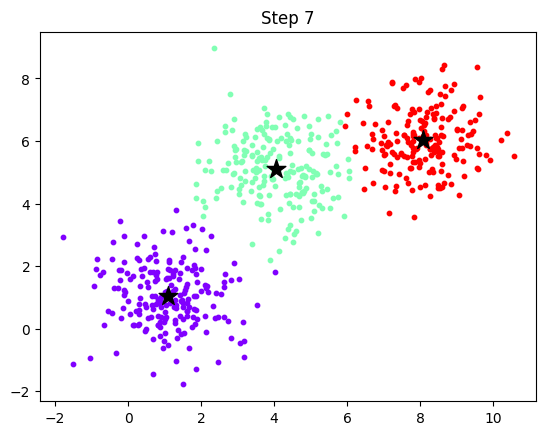

In [17]:
def k_means(data, k):
  """Finds k clusters in data, using K-means algorithm
  
  Parameters
  ----------
  data: Input data in form of (n, c), where n is the data size and c is the feature size
  k: number of expected clusters
  
  Returns
  -------
  centroids: centroids found, size of (k, c)
  clusters: list of data points with their associated clusters, size of (n, k)
  step: number of steps needed to converge
  """
  # n: data size; c: feature size;
  n = data.shape[0]
  c = data.shape[1]
  
  # Random initialization of centroids
  mean = np.mean(data, axis = 0)
  std = np.std(data, axis = 0)
  centroids = np.random.randn(k,c)*std + mean
  
  # Preparation
  old_centroids = np.zeros(centroids.shape)
  distances = np.zeros((n, k))  
  error = np.linalg.norm(centroids - old_centroids)

  # K-Means update loop
  step = 1
  while error > 1e-9:
    # Step 1: Marking each data point under each cluster
    for i in range(k):
      distances[:, i] = np.linalg.norm(data - centroids[i, :], axis=1)
    clusters = np.argmin(distances, axis=1)

    # Step 2: Updating Centroids
    old_centroids = np.copy(centroids)
    for i in range(k):
      centroids[i, :] = np.mean(data[clusters == i, :], axis=0)
    error = np.linalg.norm(centroids - old_centroids)

    step = step + 1
    
  return centroids, clusters, step
    
# Testing
k = 3
data = create_random_data()
centroids, clusters, step = k_means(data, k)
plot_clusters(data, clusters, centroids, 'Step ' + str(step))

## Elbow Method

So far, we have chosen the number of clusters intuitively and have not though much about it. What if we could find a procedure to better find the number of appropriate clusters (k). 

There is a method devised for this purpose and it is called the elbow method. The idea is simple. We plot our cost function (based on expected purpose of the clusters) with respect to the number of clusters. Usually after plotting this relation, a elbow point can be seen (similar to human elbow). Cluster numbers after this point do not result in much change in the cost, so we can choose the elbow point as the optimum number of clusters, which gives a good result and is not computationally extensive.

Using randomly generated data, we are going to create the elbow graph. The cost function used is the sum of the data point distances to closest centroid. This can show the quality of clustering, which is being closer to a centroid and farther apart from others.


/opt/anaconda3/envs/mlenv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/mlenv/lib/python3.12/site-packages/numpy/_core/_methods.py:139: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


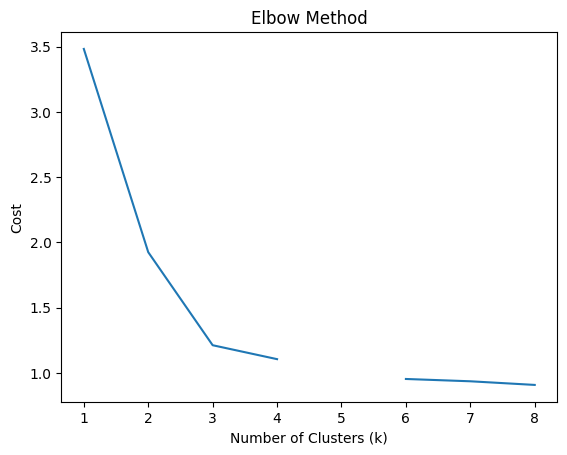

In [18]:
k = 2
costs = []
data = create_random_data()
max_k = 10
range_of_k = range(1, max_k+1)

for k in range_of_k:
  n = data.shape[0]
  centroids, clusters, step = k_means(data, k)
  distances = np.zeros((n, k))
  for i in range(k):
      distances[:, i] = np.linalg.norm(data - centroids[i, :], axis=1)
  # Cost: Normalized Sum of Distances to Closest Centroid
  cost = np.sum(np.min(distances, axis=1))/n
  costs.append(cost)

plt.plot(range_of_k, costs)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cost')  
plt.show()

As we can see, an "elbow" emerges at k equal 3. This is our expected number as the number of clusters randomly generated was 3.


# Hierarchical Clustering

Another clustering method is hierarchical clustering, which also finds some possible hierarchy in the dataset. There are two types of hierarchical clustering methods:
* **Agglomerative (bottom up)**: In this case, each point is a cluster initially. Each two nearest clusters are combined in each iteration till there is one cluster.
* **Divisive (top down)**: In this case, algorithm starts with one cluster and does division recursively to split clusters. 

In this lecture, we focus on agglomerative clustering. 

There are different items that we need to answer, such as how a cluster is represented, how closeness is measured and  when to stop combining clusters.

The clusters can be represented by their centroids, average of their data points. 

One way to set a stop criterion is to know the number of expected clusters beforehand, so the cluster merge stops when this condition is reached. Another approach is to stop when the next cluster merge results in low *cohesion*. 

There are different ways to find closeness of two clusters:
* **Single Link**: This is the distance of closest data points in two clusters.
* **Complete Link**: This is the distance between farthest elements in two clusters.
* **Average Link**: Measures average of all pairwise distances between data points of two clusters.
* **Centroids**: This is the distance between centroids (means) of two clusters.
* **Ward's Method**: This measure is based optimizing an objective function. Ward used minimum variance objective function. 

## Implementation

We will first try to implement agglomerative clustering using single linkage.

The first step is to define a function to find cluster distance between two pairs of clusters. We use single distance here.

In [19]:
from scipy.spatial.distance import cdist
import numpy as np
from numpy import inf

def single_link_cluster_distance(X, Y):
  # Please note that it replaces zero with inf as we need closest ones, not identical 

  # Euclidean distance
  distance_matrix = cdist(X, Y)
  distance_matrix[distance_matrix == 0] = inf
  return distance_matrix.min()
  
# Testing
X = np.arange(10).reshape(-1,2)
Y = np.arange(10).reshape(-1,2)
print(X)
print(Y)
distance = single_link_cluster_distance(X, Y)
print('Single link cluster distance: ', distance)

# Test 2
X = np.matrix([[2.62434536, 0.38824359]])
Y = np.matrix([[2.62434536, 0.38824359]])

distance = single_link_cluster_distance(X, Y)
print('Single link cluster distance: ', distance)

[[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]
[[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]
Single link cluster distance:  2.8284271247461903
Single link cluster distance:  inf


In [20]:
Y

matrix([[2.62434536, 0.38824359]])

In [21]:
X

matrix([[2.62434536, 0.38824359]])

Now that we have the cluster distance function, we can start from all data points as individual clusters and try to merge two of them in each iteration.

In this case, we assume that we know our target number of clusters to be achieved.

*** data matrix shape:  (30, 2)


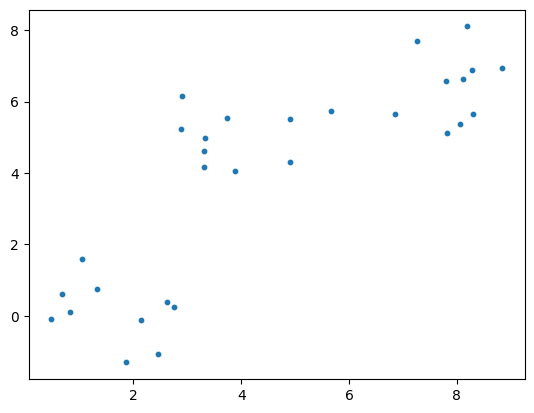

In [22]:
import numpy as np # Matrix processing
from matplotlib import pyplot as plt # Plotting

def create_sample_random_data():
  np.random.seed(1)
  # Three centroids are set
  #centroid_1 = np.array([1,1])
  #centroid_2 = np.array([5,5])
  #centroid_3 = np.array([8,1])

  centroid_1 = np.array([1,1])
  centroid_2 = np.array([4,5])
  centroid_3 = np.array([8,6])

  # Generating random data and placing them around three centroids
  data_1 = np.random.randn(10,2) + centroid_1
  data_2 = np.random.randn(10,2) + centroid_2
  data_3 = np.random.randn(10,2) + centroid_3

  data = np.concatenate((data_1, data_2, data_3), axis = 0)
  return data


data = create_sample_random_data()
plt.scatter(data[:,0], data[:,1], s=10) # s is the marker size

print('*** data matrix shape: ', data.shape)

[0 1 0 0 1 0 1 0 1 1 2 3 2 2 2 2 2 2 2 3 4 5 4 5 4 4 4 4 4 4]


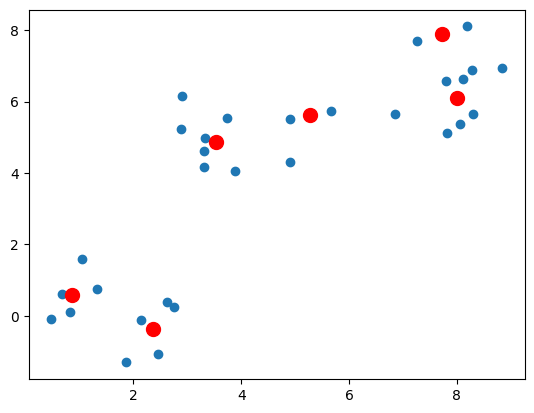

In [26]:
def get_data_points_of_cluster(data, clusters, cluster_label):
  indices = np.where(clusters == cluster_label)[0]
  return data[indices, :]

def find_closest_clusters(data, clusters):
  """
  Parameters
  ----------
  data: Data points. Shape (n, m)
  clusters: Cluster labels with shape (n,)
  
  Returns
  ----------
  x, y: cluster labels that are closest
  """
  cluster_labels = np.unique(clusters)
  cluster_count = cluster_labels.shape[0]
  distance_matrix = np.zeros((cluster_count, cluster_count))
  
  i_index = -1
  j_index = -1
  for i in cluster_labels:
    i_index = i_index + 1
    j_index = -1
    cluster_i = get_data_points_of_cluster(data, clusters, i)
    for j in cluster_labels:
      j_index = j_index + 1
      cluster_j = get_data_points_of_cluster(data, clusters, j)
      # Calculating distance between clusters i and j
      if i == j:
        distance_matrix[i_index, j_index] = inf
      else: 
        distance = single_link_cluster_distance(cluster_i, cluster_j)
        distance_matrix[i_index, j_index] = distance
  
  
  # Finding the location of least distance
  location = np.unravel_index(distance_matrix.argmin(), distance_matrix.shape)
  return cluster_labels[location[0]], cluster_labels[location[1]]
  

def hierarchical(data, num_clusters):
  """
  Input
  -----
  data: data points with shape (n, m); n: number of data points; m: dimension
  num_clusters: stop when reaching these number of clusters
  
  Returns
  -------
  clusters: List of data points with their associated cluster labels. Shape (n,)
  """
  # Initializing clusters with each point having its own cluster
  clusters = np.arange(data.shape[0])
  
  # Continue until number of clusters reached
  steps = 0
  while np.unique(clusters).shape[0] > num_clusters:
    steps = steps + 1
    # Finding closest cluster labels
    x, y = find_closest_clusters(data, clusters)
    # Merging two clusters into one
    clusters[clusters == y] = x
    
  # Creating new cluster labels from 0 to number of clusters minus 1
  unique = np.unique(clusters)
  for i in range(unique.shape[0]):
    clusters[clusters==unique[i]] = i
    
  # Calculating centroids
  centroids = np.zeros((num_clusters, data.shape[1]))
  for i in range(num_clusters):
    centroids[i, :] = np.mean(data[clusters == i, :], axis=0)
    
  # Returning data
  return clusters, steps, centroids
  
# Testing
no_of_clusters = 6
clusters, steps, centroids = hierarchical(data, no_of_clusters)
print(clusters)
#plot_clusters(data, clusters, centroids, 'Step ' + str(steps))
import matplotlib.pyplot as plt
plt.scatter(data[:, 0], data[:, 1])
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100);

## Dendogram

Dendogram plot is a a useful visualization of hierarchical clustering. The concept is easy, x-axis has the points and y-axis shows the distance, such as Euclidean. Height of each cluster merge depends on the closeness of clusters. 

One nice application of a dendogram is to visually find the appropriate number of clusters. To do this, we try to find two merged clusters that had the longest distance, or more than a threshold. If we stop before that merge, chances are we have appropriate number of clusters found.

Let's visualize this by using some sample data

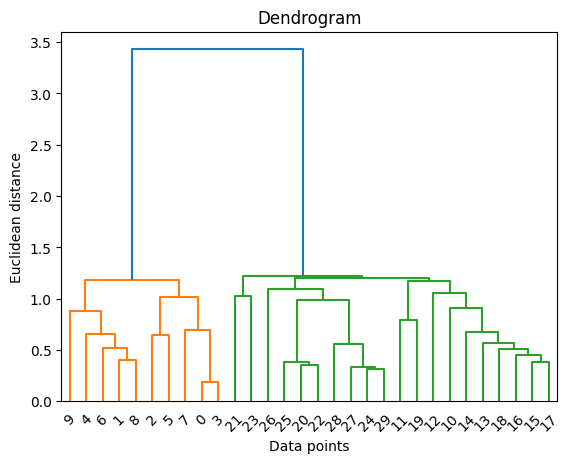

In [24]:
import scipy.cluster.hierarchy as sch
dendogram = sch.dendrogram(sch.linkage(data, method = 'single'))
plt.title('Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidean distance')
plt.show()

In this example, we can clearly see that the Euclidean distance gets quite larger when we try to merge the last three remaining clusters. This will result in three clusters as we expected.

# Other Well-known Clustering Methods

K-means is just one example of clustering methods, there are many more clustering methods and each of them uses its unique technique to find clusters in unlabled data. 

Some of the different clustering techniques can be roughly "clustered" into the following groups:
* Centroid models, such as K-Means algorithm.
* Connectivity models, such as hierarchical clustering.
* Distribution models, such as expectation-maximization (EM) algorithm.
* Density models, such as DBSCAN. 
* Subspace models, such as bi-clustering. 
* Graph-based models, such as clique.
* Neural models, such as self-organzing map.

## Short Descriptions of Algorithms

In this section, we briefly go through description of techniques for each famous clustering method. Some famous clustering algorithms, besides vanilla K-means, are:

### Mini-Batch K-Means
This is a variation of K-means that uses mini batches of data to reduce the computation time. Mini batches are subsets of the same input data, which are randomly sampled in each training iteration.

### Fuzzy Clustering
This type of clustering is also known as soft clustering as one data point can belong to multiple clusters with different probabilities.

### Fuzzy C-Means (FCM)
This algorithm is also called soft K-means. Instead of discretely specifying a data point to be part of a cluster, it provides a coefficient that shows the certainty of being part of a cluster. 

### Affinity Propagation
This type of clustering does not need the number of clusters to be specified beforehand, as in K-means. A specific similarity method between data points, such as Euclidean distance, is needed for this algorithm. Based on some criteria, some "exemplar" data points are selected to specify each cluster. Based on similarity function, data points are clustered and in next iterations exemplar points are updated and re-clustering happens again till convergence.

### Mean Shift
This is a centroid-based algorithm, similar to K-Means. This algorithm updates centroid candidates by calculating the mean of the points given in a region. 

### Spectral Clustering
To do spectral clustering, we need a similarity matrix (affinity matrix) created between all the data points. Then, we create low-dimensional embeddings for each data point. Then K-means is used in the low-dimensional embedding space to find clusters.

### DBSCAN
DBSCAN algorithm differentiates between clusters by the idea that there is a low-density region between two high-density regions. This results to have clusters of any shape. DBSCAN defines each cluster to have both core and non-core samples. Core samples are the ones in the high density area and non-core ones are in lower density areas close to core samples. Any data point that is not a core sample and has a specific distance from any core sample is considered an outlier.

### Hierarchical Clustering
This methods tries to create a hierarchy of clusters, usually represented as a tree. This type of clustering is generally categorized into two groups:
#### Agglomerative (bottom-up) 
This type of clustering starts with smaller clusters, even data points themselves, and then in each step, clusters are merged together to form a new cluster. Ultimately reaching the root of the tree as one big cluster.

There are different types of bottom-up algorithms, such as:
* **Ward**: It minimizes the variance within each cluster by minimizing the sum of squared differences within all clusters, similar to K-means, but in hierarchical manner.
* **Average Linkage**: This minimizes the average of the distances between all pair observations of clusters.

#### Divisive (top-down) 
In this approach, all the data is seen as one big cluster and then divisions recursively happen to create smaller clusters from each large cluster.

### BIRCH
BIRCH stands for Balanced Iterative Reducing and Clustering Hierarchies. This algorithm scans the dataset and creates an in-memory clustering feature tree (CF tree). Then it applies clustering algorithm to cluster the leaf nodes.
### Expectation-Maximization (EM) 
Gaussian Mixture module implements this algorithm. In this algorithm, each cluster is going to be a probability distribution. It starts by placing the random distributions (clusters) in space. For each point it tries to see which distribution it came from. No hard assignment is done, just probability of assignment. Then uses the assignments to re-estimate mean and standard deviation of the gaussian distribution. This happens until convergence.

## Comparison Table

This is an informative comparative table from the [scikit-learn documentation](https://scikit-learn.org/stable/modules/clustering.html) for your reference.

<html>

<body>
<table border="1" class="colwidths-given docutils" width="1000">
<colgroup>
<col width="15%">
<col width="16%">
<col width="20%">
<col width="27%">
<col width="22%">
</colgroup>
<thead valign="bottom">
<tr class="row-odd"><th class="head">Method name</th>
<th class="head">Parameters</th>
<th class="head">Scalability</th>
<th class="head">Usecase</th>
<th class="head">Geometry (metric used)</th>
</tr>
</thead>
<tbody valign="top">
<tr class="row-even"><td><a class="reference internal" href="#k-means"><span class="std std-ref">K-Means</span></a></td>
<td>number of clusters</td>
<td>Very large <code class="docutils literal"><span class="pre">n_samples</span></code><br>, medium <code class="docutils literal"><span class="pre">n_clusters</span></code> with<br>
<a class="reference internal" href="#mini-batch-kmeans"><span class="std std-ref">MiniBatch code</span></a></td>
<td>General-purpose, even cluster size,<br> flat geometry, not too many clusters</td>
<td>Distances between points</td>
</tr>
<tr class="row-odd"><td><a class="reference internal" href="#affinity-propagation"><span class="std std-ref">Affinity propagation</span></a></td>
<td>damping,<br> sample preference</td>
<td>Not scalable with n_samples</td>
<td>Many clusters, uneven cluster size,<br> non-flat geometry</td>
<td>Graph distance<br>(e.g. nearest-neighbor graph)</td>
</tr>
<tr class="row-even"><td><a class="reference internal" href="#mean-shift"><span class="std std-ref">Mean-shift</span></a></td>
<td>bandwidth</td>
<td>Not scalable with <code class="docutils literal"><span class="pre">n_samples</span></code></td>
<td>Many clusters, uneven cluster size,<br> non-flat geometry</td>
<td>Distances between points</td>
</tr>
<tr class="row-odd"><td><a class="reference internal" href="#spectral-clustering"><span class="std std-ref">Spectral clustering</span></a></td>
<td>number of clusters</td>
<td>Medium <code class="docutils literal"><span class="pre">n_samples</span></code>, small <br><code class="docutils literal"><span class="pre">n_clusters</span></code></td>
<td>Few clusters, even cluster size,<br> non-flat geometry</td>
<td>Graph distance<br>(e.g. nearest-neighbor graph)</td>
</tr>
<tr class="row-even"><td><a class="reference internal" href="#hierarchical-clustering"><span class="std std-ref">Ward hierarchical clustering</span></a></td>
<td>number of clusters</td>
<td>Large <code class="docutils literal"><span class="pre">n_samples</span></code> and<br> <code class="docutils literal"><span class="pre">n_clusters</span></code></td>
<td>Many clusters,<br> possibly connectivity constraints</td>
<td>Distances between points</td>
</tr>
<tr class="row-odd"><td><a class="reference internal" href="#hierarchical-clustering"><span class="std std-ref">Agglomerative clustering</span></a></td>
<td>number of clusters,<br> linkage type, distance</td>
<td>Large <code class="docutils literal"><span class="pre">n_samples</span></code> and<br> <code class="docutils literal"><span class="pre">n_clusters</span></code></td>
<td>Many clusters,<br> possibly connectivity constraints,<br> non Euclidean
distances</td>
<td>Any pairwise distance</td>
</tr>
<tr class="row-even"><td><a class="reference internal" href="#dbscan"><span class="std std-ref">DBSCAN</span></a></td>
<td>neighborhood size</td>
<td>Very large <code class="docutils literal"><span class="pre">n_samples</span></code><br>, medium <code class="docutils literal"><span class="pre">n_clusters</span></code></td>
<td>Non-flat geometry, uneven cluster sizes</td>
<td>Distances between nearest points</td>
</tr>
<tr class="row-odd"><td><a class="reference internal" href="mixture.html#mixture"><span class="std std-ref">Gaussian mixtures</span></a></td>
<td>many</td>
<td>Not scalable</td>
<td>Flat geometry, good for density estimation</td>
<td>Mahalanobis distances to centers</td>
</tr>
<tr class="row-even"><td><a class="reference internal" href="#birch"><span class="std std-ref">Birch</span></a></td>
<td>branching factor, <br>threshold,<br> optional global clusterer.</td>
<td>Large <code class="docutils literal"><span class="pre">n_clusters</span></code> and<br> <code class="docutils literal"><span class="pre">n_samples</span></code></td>
<td>Large dataset, outlier removal,<br> data reduction.</td>
<td>Euclidean distance between points</td>
</tr>
</tbody>
</table>

</body>

</html>

# Using scikit-learn

## Implementation

To implement different clustering algorithms, we use a useful machine learning package, called [*scikit-learn*](https://scikit-learn.org/stable/). To demonstrate the usage of this package, we implement the same K-means algorithm, but this time using the scikit-learn package ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans)). In the next section, we use a code from scikit-learn to compare different clustering methods on different distributions of 2D data and see which algorithm performs better in each of these scenarios.

In [27]:
pip install threadpoolctl==3.1.0

Note: you may need to restart the kernel to use updated packages.


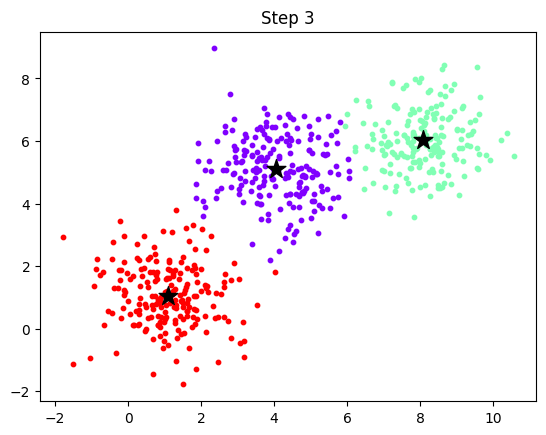

In [28]:
from sklearn.cluster import KMeans

k = 3
data = create_random_data() # Generatin random data (same as before)
kmeans = KMeans(k, random_state=0).fit(data) # Running K-Mean algorithm
#X = np.array([[1, 2], [1, 4], [1, 0], [10, 2], [10, 4], [10, 0]])
#kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
clusters = kmeans.labels_ # Getting cluster labels
centroids = kmeans.cluster_centers_ # Predicted centroids
steps = kmeans.n_iter_ # Steps till convergence
plot_clusters(data, clusters, centroids, 'Step ' + str(steps))

## Comparison

The following code is used from scikit-lear tutorials. It demonstrates how different algorithms can cluster various two-dimensional data. Each row is a specific dataset and each column is a specific algorithm. The last dataset is uniform with no specific clusters. The running time of each algorithm is printed at bottom-right of each figure.

Please note that this experiment gives some intuition about 2D clustering and this intuition may not extend to higher dimensions. The code may take up to a few minutes to run.

Automatically created module for IPython interactive environment


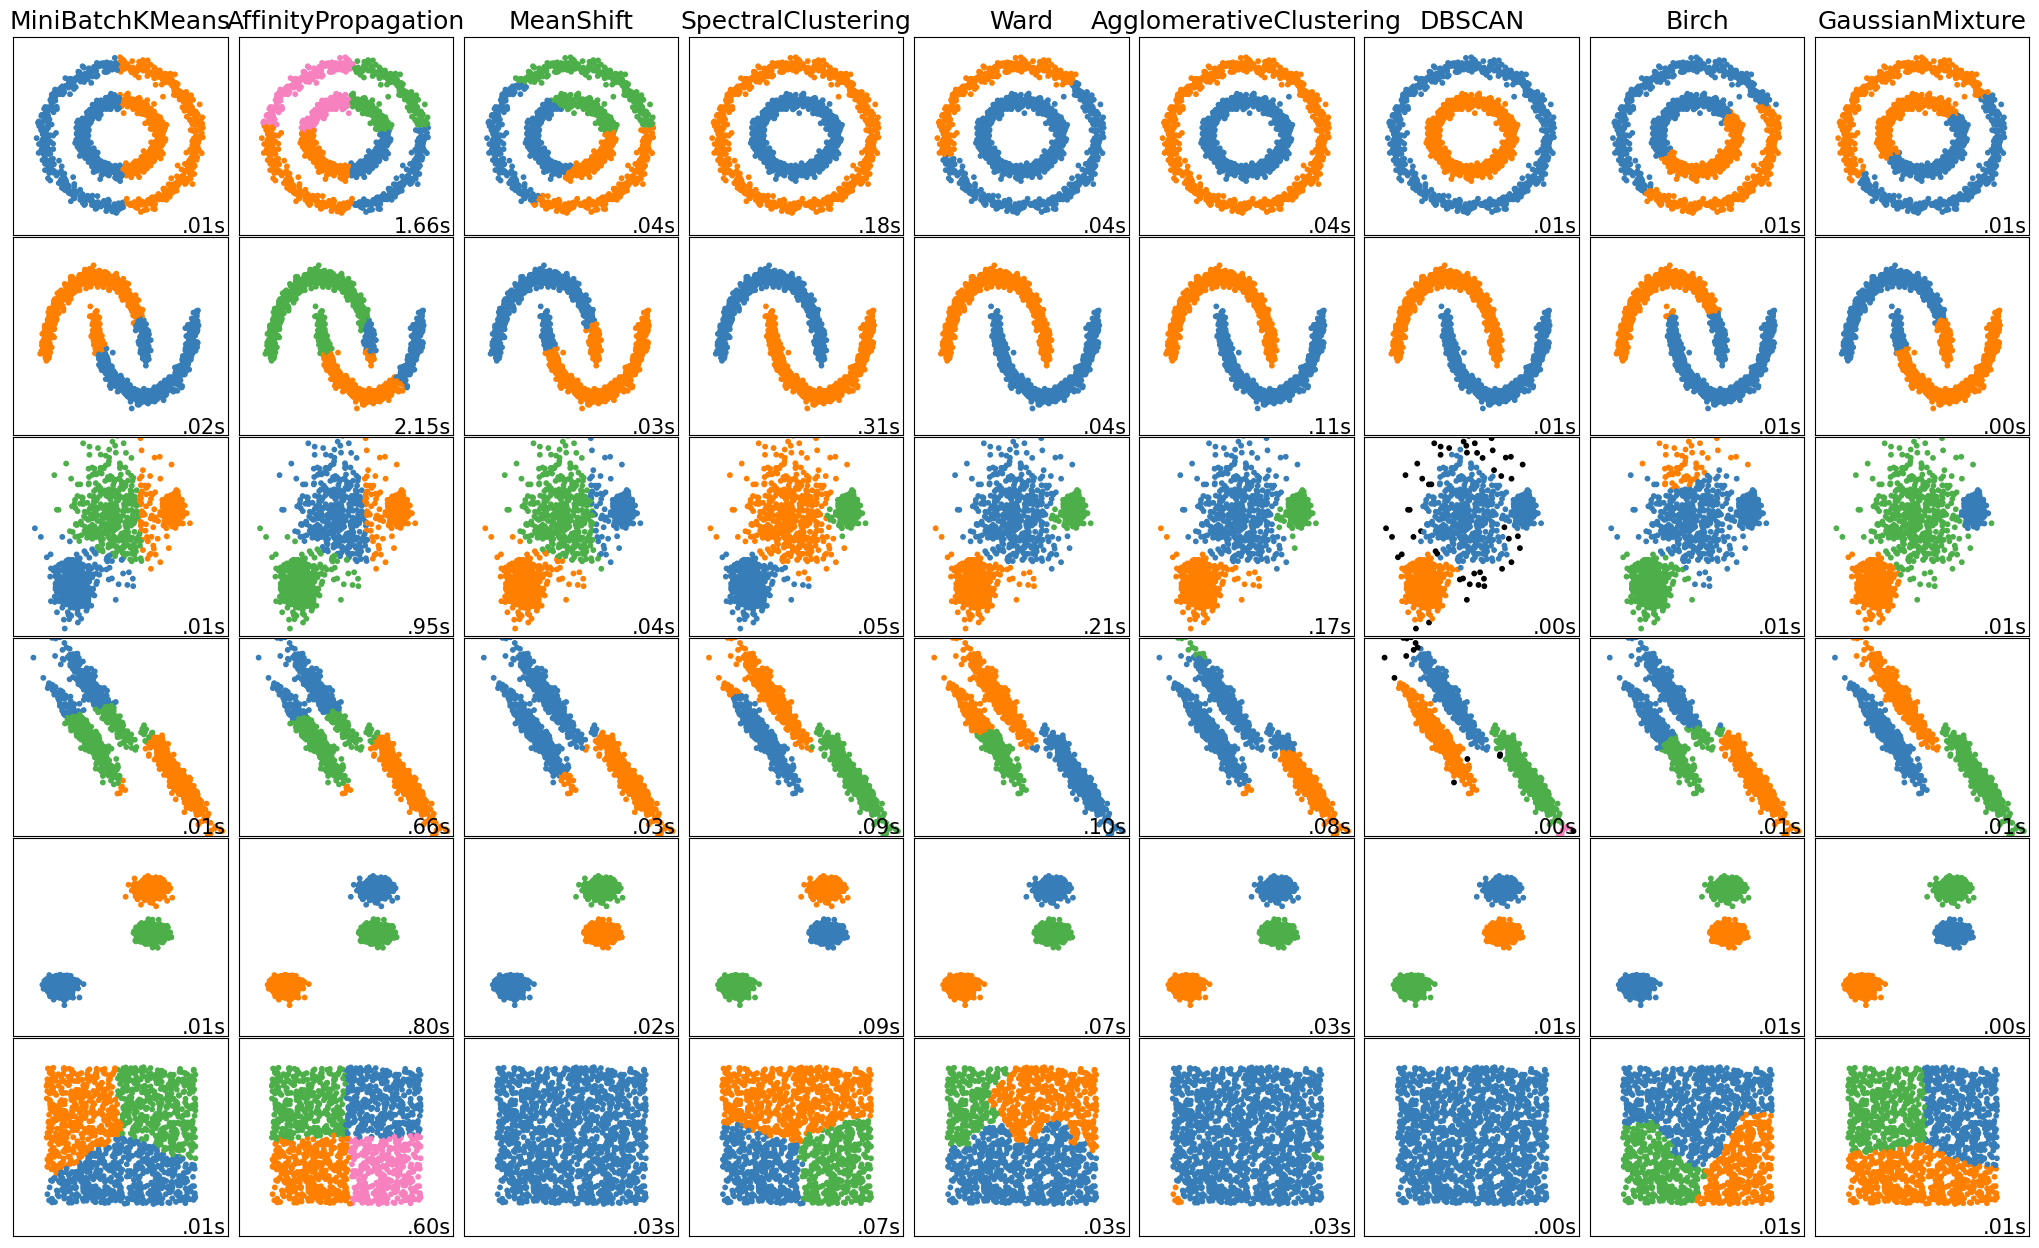

In [29]:
print(__doc__)

import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

np.random.seed(0)

# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=.5,
                                      noise=.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(n_samples=n_samples,
                             cluster_std=[1.0, 2.5, 0.5],
                             random_state=random_state)

# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(9 * 2 + 3, 12.5))
plt.subplots_adjust(left=.02, right=.98, bottom=.001, top=.96, wspace=.05,
                    hspace=.01)

plot_num = 1

default_base = {'quantile': .3,
                'eps': .3,
                'damping': .9,
                'preference': -200,
                'n_neighbors': 10,
                'n_clusters': 3}

datasets = [
    (noisy_circles, {'damping': .77, 'preference': -240,
                     'quantile': .2, 'n_clusters': 2}),
    (noisy_moons, {'damping': .75, 'preference': -220, 'n_clusters': 2}),
    (varied, {'eps': .18, 'n_neighbors': 2}),
    (aniso, {'eps': .15, 'n_neighbors': 2}),
    (blobs, {}),
    (no_structure, {})]

for i_dataset, (dataset, algo_params) in enumerate(datasets):
    # update parameters with dataset-specific values
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    # normalize dataset for easier parameter selection
    X = StandardScaler().fit_transform(X)

    # estimate bandwidth for mean shift
    bandwidth = cluster.estimate_bandwidth(X, quantile=params['quantile'])

    # connectivity matrix for structured Ward
    connectivity = kneighbors_graph(
        X, n_neighbors=params['n_neighbors'], include_self=False)
    # make connectivity symmetric
    connectivity = 0.5 * (connectivity + connectivity.T)

    # ============
    # Create cluster objects
    # ============
    ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
    two_means = cluster.MiniBatchKMeans(n_clusters=params['n_clusters'])
    ward = cluster.AgglomerativeClustering(
        n_clusters=params['n_clusters'], linkage='ward',
        connectivity=connectivity)
    spectral = cluster.SpectralClustering(
        n_clusters=params['n_clusters'], eigen_solver='arpack',
        affinity="nearest_neighbors")
    dbscan = cluster.DBSCAN(eps=params['eps'])
    affinity_propagation = cluster.AffinityPropagation(
        damping=params['damping'], preference=params['preference'])
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average", metric="cityblock",
        #linkage="average", affinity="cityblock",
        n_clusters=params['n_clusters'], connectivity=connectivity)
    birch = cluster.Birch(n_clusters=params['n_clusters'])
    gmm = mixture.GaussianMixture(
        n_components=params['n_clusters'], covariance_type='full')

    clustering_algorithms = (
        ('MiniBatchKMeans', two_means),
        ('AffinityPropagation', affinity_propagation),
        ('MeanShift', ms),
        ('SpectralClustering', spectral),
        ('Ward', ward),
        ('AgglomerativeClustering', average_linkage),
        ('DBSCAN', dbscan),
        ('Birch', birch),
        ('GaussianMixture', gmm)
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        # catch warnings related to kneighbors_graph
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="the number of connected components of the " +
                "connectivity matrix is [0-9]{1,2}" +
                " > 1. Completing it to avoid stopping the tree early.",
                category=UserWarning)
            warnings.filterwarnings(
                "ignore",
                message="Graph is not fully connected, spectral embedding" +
                " may not work as expected.",
                category=UserWarning)
            algorithm.fit(X)

        t1 = time.time()
        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(np.int64)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(list(islice(cycle(['#377eb8', '#ff7f00', '#4daf4a',
                                             '#f781bf', '#a65628', '#984ea3',
                                             '#999999', '#e41a1c', '#dede00']),
                                      int(max(y_pred) + 1))))
        # add black color for outliers (if any)
        colors = np.append(colors, ["#000000"])
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])

        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(.99, .01, ('%.2fs' % (t1 - t0)).lstrip('0'),
                 transform=plt.gca().transAxes, size=15,
                 horizontalalignment='right')
        plot_num += 1

plt.show()

# Recap
In this tutorial, we got a sense of what unsupervised algorithms are. We looked at various clustering algorithms and their implementations. We also compared them on different datasets and briefly talked about their applications.

# References
* Coursera Machine Learning Course: https://www.coursera.org/learn/machine-learning
* Kaggle K-means: https://www.kaggle.com/andyxie/k-means-clustering-implementation-in-python
* scikit-learn: https://scikit-learn.org/stable/
* Why so many clustering algorithms: https://dl.acm.org/citation.cfm?id=568575
* Mining of Massive Datasets: http://www.mmds.org/
